# Import Library

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans
)
from sklearn.metrics import silhouette_score


# Load Dataset

In [78]:
print("Loading dataset...")
df = pd.read_csv('../data/processed_dataset.csv') 
print(f"Dataset berhasil di-load dengan dimensi: {df.shape}")
df.head()

Loading dataset...
Dataset berhasil di-load dengan dimensi: (99994, 80)


,derived_msa_md,state_code,county_code,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,preapproval,lien_status,reverse_mortgage,loan_amount,...,loan_purpose_32,loan_purpose_4,loan_purpose_5,income_bracket_High,income_bracket_Low,income_bracket_Medium,income_bracket_Very High,loan_size_Large,loan_size_Medium,loan_size_Small
0,12580,md,24005.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,465000,...,0,0,0,0,0,0,1,1,0,0
1,22220,ar,5007.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,125000,...,0,0,0,0,0,0,1,0,0,1
2,43900,sc,45083.0,c,conventional:subordinate lien,single family (1-4 units):site-built,2,2,2,55000,...,0,1,0,0,0,0,0,0,0,1
3,19430,oh,39057.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,65000,...,0,0,0,0,1,0,0,0,0,1
4,41700,tx,48029.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,125000,...,0,0,0,0,0,0,0,0,0,1


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99994 entries, 0 to 99993
Data columns (total 80 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   derived_msa_md                                          99994 non-null  int64  
 1   state_code                                              98860 non-null  str    
 2   county_code                                             98187 non-null  float64
 3   conforming_loan_limit                                   99569 non-null  str    
 4   derived_loan_product_type                               99994 non-null  str    
 5   derived_dwelling_category                               99994 non-null  str    
 6   preapproval                                             99994 non-null  int64  
 7   lien_status                                             99994 non-null  int64  
 8   reverse_mortgage                               

# Select Feature and Sample

In [80]:
sample_df = df.sample(
    n=min(15000, len(df)),
    random_state=42
)


sample_df.shape

X = sample_df.select_dtypes(
    include=np.number
)

print("Jumlah feature:", X.shape[1])
print("Jumlah data:", X.shape[0])
X.head()

Jumlah feature: 65
Jumlah data: 15000


,derived_msa_md,county_code,preapproval,lien_status,reverse_mortgage,loan_amount,hoepa_status,construction_method,occupancy_type,income,...,loan_purpose_32,loan_purpose_4,loan_purpose_5,income_bracket_High,income_bracket_Low,income_bracket_Medium,income_bracket_Very High,loan_size_Large,loan_size_Medium,loan_size_Small
33965,45780,39095.0,2,1,2,125000,3,1,1,52.0,...,0,0,0,0,1,0,0,0,0,1
22853,41940,6085.0,2,1,2,645000,3,1,1,420.0,...,1,0,0,0,0,0,1,1,0,0
19448,26420,48201.0,2,1,2,575000,2,1,1,138.0,...,0,0,0,1,0,0,0,1,0,0
9732,24860,45045.0,2,1,2,1065000,3,1,1,196.0,...,0,0,0,0,0,0,1,1,0,0
7129,41700,48029.0,2,2,2,35000,2,1,1,125.0,...,0,0,0,1,0,0,0,0,0,1


# Cek Missing Values and Input with Median

In [81]:
df.isnull().sum()

derived_msa_md                  0
state_code                   1134
county_code                  1807
conforming_loan_limit         425
derived_loan_product_type       0
                             ... 
income_bracket_Medium           0
income_bracket_Very High        0
loan_size_Large                 0
loan_size_Medium                0
loan_size_Small                 0
Length: 80, dtype: int64

In [82]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns


for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )


df.isnull().sum().sum()

264685

# Remove Duplicate

In [83]:
print(
    "Before:",
    df.shape
)


df = df.drop_duplicates()


print(
    "After:",
    df.shape
)

Before: (99994, 80)
After: (99993, 80)


# Select Sample 

In [84]:
sample_size = min(
    15000,
    len(df)
)


sample_df = df.sample(
    n=sample_size,
    random_state=42
)


print(
    sample_df.shape
)

(15000, 80)


# Select Numeric Feature

In [86]:
X = sample_df.select_dtypes(
    include=np.number
)

# Scalling

In [87]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X
)


X_scaled.shape

(15000, 65)

# PCA

In [89]:
pca = PCA(
    n_components=5,
    random_state=42
)


X_pca = pca.fit_transform(
    X_scaled
)


print(
    X_pca.shape
)


print(
    "Total variance:",
    pca.explained_variance_ratio_.sum()
)

(15000, 5)
Total variance: 0.23541835839335706


# Hierarchical Clustering

In [91]:
scores = []


range_k = range(
    2,
    11
)


for k in range_k:

    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )


    labels = hc.fit_predict(
        X_pca
    )


    score = silhouette_score(
        X_pca,
        labels
    )


    scores.append(score)

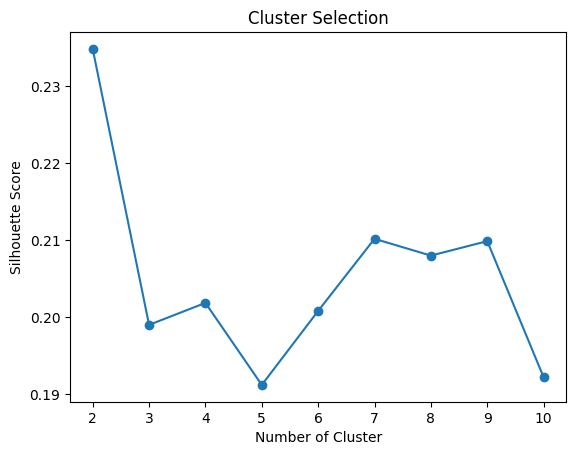

In [92]:
plt.plot(
    list(range_k),
    scores,
    marker="o"
)


plt.xlabel(
    "Number of Cluster"
)


plt.ylabel(
    "Silhouette Score"
)


plt.title(
    "Cluster Selection"
)


plt.show()

# Choose Best K

In [93]:
best_k = list(range_k)[
    np.argmax(scores)
]


print(
    "Best K:",
    best_k
)

Best K: 2


# Use Kmeans Using Best K

In [96]:
# ==========================================
# KMEANS FINAL
# ==========================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)


cluster = kmeans.fit_predict(
    X_pca
)


sample_df["Cluster"] = cluster

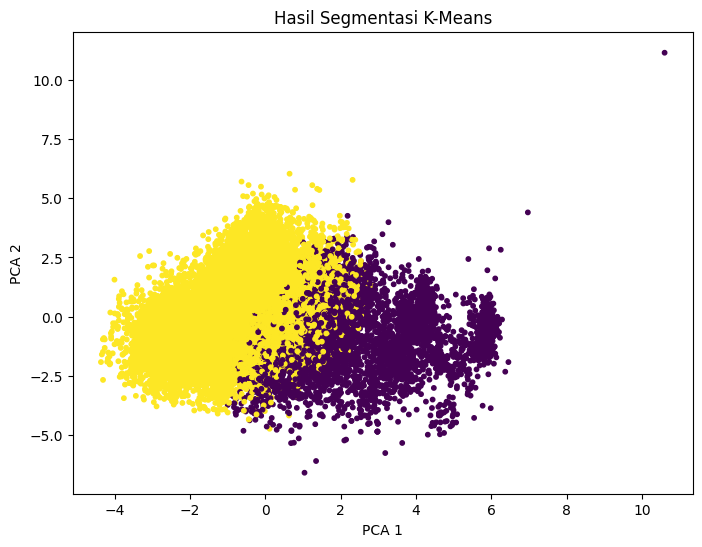

In [100]:
# ==========================================
# FINAL CLUSTER VISUALIZATION
# ==========================================


plt.figure(figsize=(8,6))


plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster,
    s=10
)


plt.title(
    "Hasil Segmentasi K-Means"
)


plt.xlabel(
    "PCA 1"
)


plt.ylabel(
    "PCA 2"
)


plt.show()

In [101]:
sample_df["Cluster"].value_counts()

Cluster
1    11297
0     3703
Name: count, dtype: int64

In [97]:
final_silhouette = silhouette_score(
    X_pca,
    cluster
)


print(
    "Final Silhouette Score:",
    final_silhouette
)

Final Silhouette Score: 0.25794798296709953


In [103]:
cluster_profile = (
    sample_df
    .select_dtypes(include=np.number)
    .groupby(sample_df["Cluster"])
    .mean()
)


cluster_profile

,derived_msa_md,county_code,preapproval,lien_status,reverse_mortgage,loan_amount,hoepa_status,construction_method,occupancy_type,income,...,loan_purpose_32,loan_purpose_4,loan_purpose_5,income_bracket_High,income_bracket_Low,income_bracket_Medium,income_bracket_Very High,loan_size_Large,loan_size_Medium,loan_size_Small
Cluster,,,,,,,,,,,,,,,,,,,,,
0,35797.211180,27220.547124,1.980286,1.109641,22.357278,386571.698623,2.416959,1.026195,1.285444,136.293816,...,0.215231,0.052390,0.018904,0.165812,0.136376,0.149608,0.177964,0.389684,0.336754,0.273562
1,38111.920244,27958.450562,1.965566,1.185979,20.939187,275488.625299,2.465168,1.050456,1.131539,154.027706,...,0.198460,0.089581,0.000089,0.233867,0.256351,0.247322,0.238205,0.309109,0.308666,0.382225
